# Kinase fusion analysis

Here, we take the fusion genes that include kinases and analyze them to understand what new domain combinations are being created with the kinase domain and if there are biases for either the pTyr or pSer/Thr systems.

In [ ]:
import dansy
import pandas as pd
import numpy as np
import scipy.stats as stats
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from collections import Counter

In [2]:
# Now let's set up a handful of matplotlib default values
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['axes.linewidth'] = 0.5
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.01
plt.rcParams['lines.markeredgewidth'] = 0.01
plt.rcParams['figure.dpi'] = 300

In [3]:
# We have the dansy results from tcga and ccle already so let's import them
tcga_dansy_res = pd.read_csv('260324_Individual_Fusion_Summary_info.csv', index_col = 0)
ccle_dansy_res = pd.read_csv('260324_CCLE_dansy_fusion.csv', index_col=0)

for x in ['domain_architecture', 'dansy_impact','h_contribution','t_contribution']:
    tcga_dansy_res[x].fillna('', inplace=True)
    ccle_dansy_res[x].fillna('', inplace=True)

In [4]:
# Now let's limit the analysis to individual fusion proteins and not the breakpoints
tcga_dansy_res = tcga_dansy_res.filter(['name','PatientID','dansy_impact', 'domain_architecture','h_uniprot','t_uniprot','h_contribution','t_contribution','id']).drop_duplicates(subset = ['name', 'PatientID', 'dansy_impact', 'domain_architecture'])
ccle_dansy_res = ccle_dansy_res.filter(['fusion_protein','ModelID','dansy_impact', 'domain_architecture','h_uniprot','t_uniprot','h_contribution','t_contribution','id']).drop_duplicates(subset = ['fusion_protein', 'ModelID', 'dansy_impact', 'domain_architecture'])

In [5]:
# Now getting the ptyr and pser/thr kinases
tyr_sys = pd.read_csv('data/Current_Multispecies_Files/H_sapiensFull_pTyr_System_Reference_File_2026_0324.csv')
serthr_sys = pd.read_csv('data/Current_Multispecies_Files/H_sapiensFull_pSerThr_System_Reference_File_2026_0324.csv')

# Kinases only
tyr_kins = tyr_sys[tyr_sys['Interpro Domains'].apply(lambda x: 'IPR000719' in x)]
tyr_kins = dansy.ngramUtilities.add_Interpro_ID_architecture(tyr_kins)
serthr_kins = serthr_sys[serthr_sys['Interpro Domains'].apply(lambda x: 'IPR000719' in x)]
serthr_kins = dansy.ngramUtilities.add_Interpro_ID_architecture(serthr_kins)
# For the kinases that are dual specificity keeping them only in the tyr kinase cases for the time being
serthr_kins = serthr_kins[~serthr_kins['UniProt ID'].isin(tyr_kins['UniProt ID'])]
all_kins = set(tyr_kins['UniProt ID']).union(serthr_kins['UniProt ID'])

In [6]:
# Let's get the natural n-grams so we can highlight the novel ones within the network.
ref_df = dansy.import_proteome_files(ref_file_dir='./data/Current_Human_Proteome',
                                     ref_file_suffix='2026_0324.csv')
kinase_net = dansy.dansy(protsOI = list(set(serthr_kins['UniProt ID']).union(tyr_kins['UniProt ID'])), ref = ref_df, n = 15, collapse = False)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [7]:
tcga_dansy_res['tk'] = tcga_dansy_res[['h_uniprot','t_uniprot']].isin(tyr_kins['UniProt ID'].values).any(axis = 1)
tcga_dansy_res['stk'] = tcga_dansy_res[['h_uniprot','t_uniprot']].isin(serthr_kins['UniProt ID'].values).any(axis = 1)
tcga_dansy_res['novel'] = tcga_dansy_res.dansy_impact.apply(lambda x: "Novel" in x)
tcga_dansy_res['retain'] = tcga_dansy_res.domain_architecture.apply(lambda x: "IPR000719" in x) 
ccle_dansy_res['tk'] = ccle_dansy_res[['h_uniprot','t_uniprot']].isin(tyr_kins['UniProt ID'].values).any(axis = 1)
ccle_dansy_res['stk'] = ccle_dansy_res[['h_uniprot','t_uniprot']].isin(serthr_kins['UniProt ID'].values).any(axis = 1)
ccle_dansy_res['novel'] = ccle_dansy_res.dansy_impact.apply(lambda x: "Novel" in x)
ccle_dansy_res['retain'] = ccle_dansy_res.domain_architecture.apply(lambda x: "IPR000719" in x) 

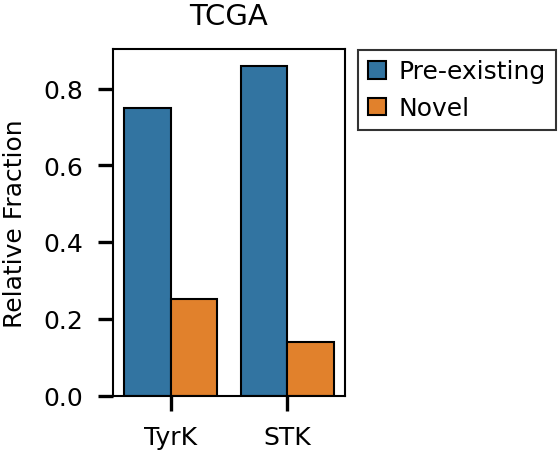

In [8]:
x1 = pd.crosstab(tcga_dansy_res.tk,tcga_dansy_res.novel, normalize='index').loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(tcga_dansy_res.stk,tcga_dansy_res.novel, normalize='index').loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'STK'})
tcga_kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'novel').dropna()
ax = sns.barplot(tcga_kin_sum, x = 'variable',
                 y = 'value', hue = 'novel',
                 linewidth = 0.5, edgecolor = 'k')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title=None, fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,
           edgecolor = 'k').get_frame().set_linewidth(0.5)


plt.xlabel(None)
plt.ylabel('Relative Fraction',fontdict={'fontsize':6})
plt.title('TCGA',fontdict={'fontsize':7})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.savefig('Figures/Manuscript/Figure_4/4B_Relative_Fraction_Novel_Kinase_fusions.svg')

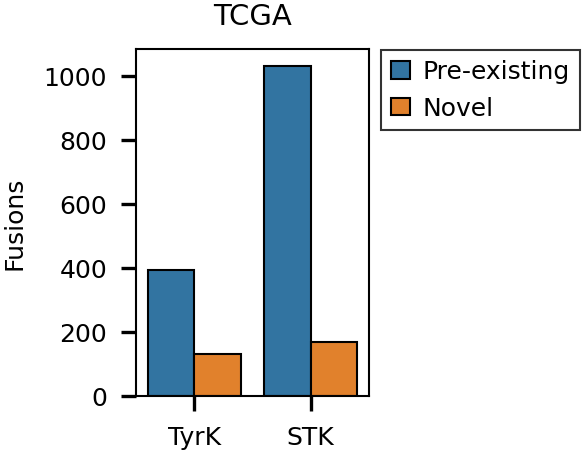

In [9]:
x1 = pd.crosstab(tcga_dansy_res.tk,tcga_dansy_res.novel).loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(tcga_dansy_res.stk,tcga_dansy_res.novel).loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'STK'})
tcga_kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'novel').dropna()
ax = sns.barplot(tcga_kin_sum, 
                 x = 'variable', y = 'value', 
                 hue = 'novel',
                 linewidth = 0.5, edgecolor = 'k')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title=None, fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,
           edgecolor = 'k').get_frame().set_linewidth(0.5)
plt.xlabel(None)
plt.ylabel('Fusions',fontdict={'fontsize':6})
plt.title('TCGA',fontdict={'fontsize':7})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.savefig('Figures/Manuscript/Supplemental_Figure_15/S15A_TCGA_Count_Novel_Kinase_fusions.svg')

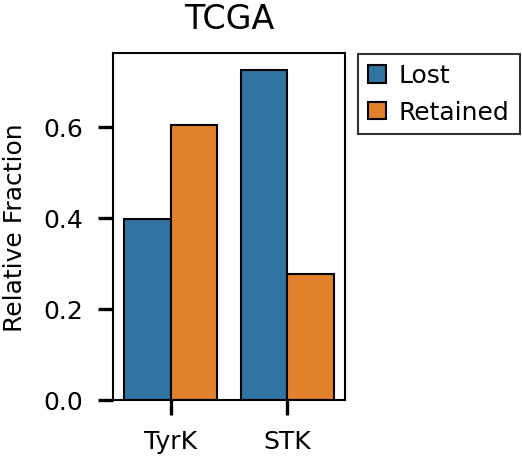

In [10]:
x1 = pd.crosstab(tcga_dansy_res.tk,tcga_dansy_res.retain, normalize='index').loc[True].rename(index={False:'Lost',True:'Retained'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(tcga_dansy_res.stk,tcga_dansy_res.retain, normalize='index').loc[True].rename(index={False:'Lost',True:'Retained'}).reset_index().rename(columns={True:'STK'})
tcga_kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'retain').dropna()
ax = sns.barplot(tcga_kin_sum, 
                 x = 'variable', y = 'value', hue = 'retain',
                 linewidth = 0.5, edgecolor = 'k')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title=None, fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,
           edgecolor = 'k').get_frame().set_linewidth(0.5)


plt.xlabel(None)
plt.ylabel('Relative Fraction',fontdict={'fontsize':6})
plt.title('TCGA',fontdict={'fontsize':8})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.savefig('Figures/Manuscript/Figure_4/4C_Retained_Kinase_domain_fusions.svg')

In [11]:
# Relative fraction of kinase domains retained across all kinase fusions
tcga_dansy_res[tcga_dansy_res.tk | tcga_dansy_res.stk].retain.sum()/len(tcga_dansy_res[tcga_dansy_res.tk | tcga_dansy_res.stk])

0.37383177570093457

In [12]:
# Number of kinase fusions
len(tcga_dansy_res[tcga_dansy_res.tk | tcga_dansy_res.stk])

1712

Repeating with the CCLE

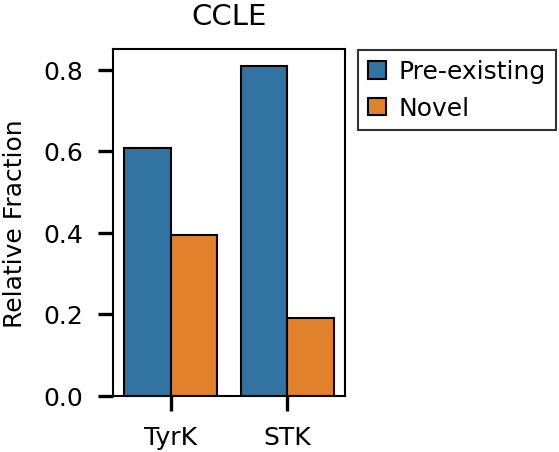

In [13]:
x1 = pd.crosstab(ccle_dansy_res.tk,ccle_dansy_res.novel, normalize='index').loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(ccle_dansy_res.stk,ccle_dansy_res.novel, normalize='index').loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'STK'})
ccle_kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'novel').dropna()
ax = sns.barplot(ccle_kin_sum, 
                 x = 'variable', y = 'value', hue = 'novel',
                 linewidth = 0.5, edgecolor = 'k')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title=None, fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,
           edgecolor = 'k').get_frame().set_linewidth(0.5)


plt.xlabel(None)
plt.ylabel('Relative Fraction',fontdict={'fontsize':6})
plt.title('CCLE',fontdict={'fontsize':7})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.savefig('Figures/Manuscript/Supplemental_Figure_15/S15A_Retained_Kinase_domain_fusions.svg')

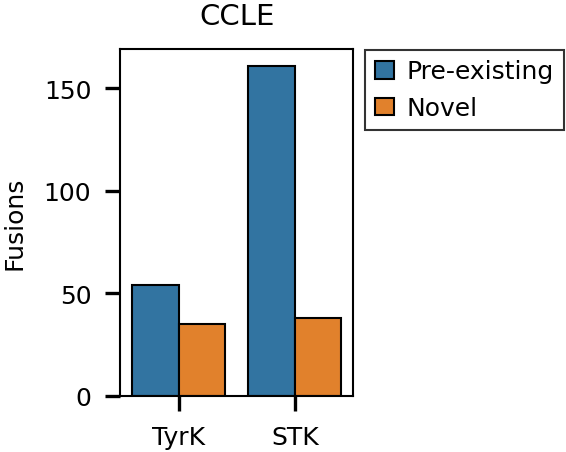

In [14]:
x1 = pd.crosstab(ccle_dansy_res.tk,ccle_dansy_res.novel).loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(ccle_dansy_res.stk,ccle_dansy_res.novel).loc[True].rename(index={False:'Pre-existing',True:'Novel'}).reset_index().rename(columns={True:'STK'})
ccle_kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'novel').dropna()
ax = sns.barplot(ccle_kin_sum, 
                 x = 'variable', y = 'value', hue = 'novel',
                 edgecolor = 'k', linewidth = 0.5)
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title=None, fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,
           edgecolor = 'k').get_frame().set_linewidth(0.5)


plt.xlabel(None)
plt.ylabel('Fusions',fontdict={'fontsize':6})
plt.title('CCLE',fontdict={'fontsize':7})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.savefig('Figures/Manuscript/Supplemental_Figure_15/S15B_Count_Kinase_domain_fusions.svg')

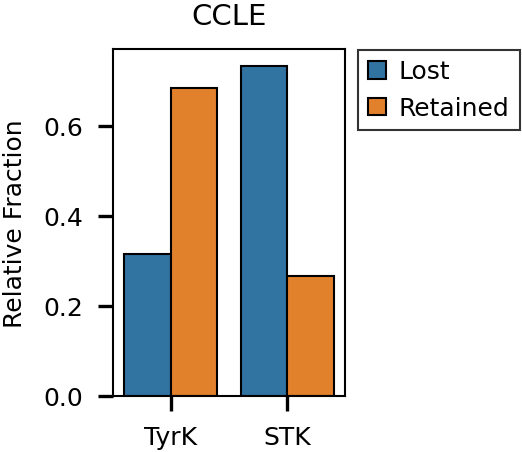

In [15]:
x1 = pd.crosstab(ccle_dansy_res.tk,ccle_dansy_res.retain, normalize='index').loc[True].rename(index={False:'Lost',True:'Retained'}).reset_index().rename(columns={True:'TyrK'})
x2 = pd.crosstab(ccle_dansy_res.stk,ccle_dansy_res.retain, normalize='index').loc[True].rename(index={False:'Lost',True:'Retained'}).reset_index().rename(columns={True:'STK'})
kin_sum = pd.concat([x1,x2], axis = 0,ignore_index= True).melt(id_vars = 'retain').dropna()
ax = sns.barplot(kin_sum, 
                 x = 'variable', y = 'value', hue = 'retain',
                 linewidth = 0.5, edgecolor = 'k')
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles,labels,
           loc = 'upper left', bbox_to_anchor = (1,1.035), 
           title=None, fontsize= 6, fancybox=False,
           handletextpad = 0.5,handlelength = 0.75,
           edgecolor = 'k').get_frame().set_linewidth(0.5)


plt.xlabel(None)
plt.ylabel('Relative Fraction',fontdict={'fontsize':6})
plt.title('CCLE',fontdict={'fontsize':7})
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.,1.5)
plt.tick_params(labelsize=6)
plt.savefig('Figures/Manuscript/Supplemental_Figure_15/S15C_Retained_Kinase_domain_fusions.svg')

# Building a DANSy n-gram network to evaluate kinase fusions

An unfortunate aspect of the base dansy class is that it is currently built to take in a reference file generated by CoDIAC, but we can get around that by using specific pieces of it.

In [16]:
tcga_kins_only = tcga_dansy_res[(tcga_dansy_res.tk | tcga_dansy_res.stk) & (tcga_dansy_res.retain)].copy()
tcga_kin_all_ngrams = dansy.ngramUtilities.return_ngrams_from_list(tcga_kins_only.domain_architecture,21)

tcga_ngram_id_dict = {}
for ngram in tcga_kin_all_ngrams:
    ids = tcga_kins_only[tcga_kins_only.domain_architecture.apply(lambda x: ngram in x)]['id'].values
    tcga_ngram_id_dict[ngram] = ids

tcga_kin_ngrams,tcga_kin_collapsed_ngrams = dansy.ngramUtilities.concatenate_ngrams(tcga_ngram_id_dict,21) 
tcga_kin_adj = dansy.ngramUtilities.return_ngram_adjacency(tcga_kin_ngrams)
tcga_kin_adj.fillna(0,inplace=True)


In [17]:
tcga_prots_net = dansy.dansy(protsOI=list(set(tcga_kins_only.h_uniprot).union(tcga_kins_only.t_uniprot)), ref = ref_df, n = 21, collapse = False)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [18]:
G = nx.from_pandas_adjacency(tcga_kin_adj)
G.remove_edges_from(nx.selfloop_edges(G))

In [19]:
pos = nx.nx_agraph.graphviz_layout(G,prog='sfdp')


In [20]:
# Let's make a dictionary to help identify if the domain n-gram is associated with the TKs and/or STKs
ngram_kintype = {}
for ngram, ids in tcga_ngram_id_dict.items():
    infoOI = tcga_kins_only[tcga_kins_only.id.isin(ids)]
    tk_check = infoOI.tk.any()
    stk_check = infoOI.stk.any()
    if tk_check and stk_check:
        kin_type = 'Both'
    elif stk_check:
        kin_type = 'STK'
    elif tk_check:
        kin_type = 'TyrK'
    else:
        raise ValueError('Something went wrong')
    
    ngram_kintype[ngram] = kin_type

# Now create a color mapper
col_map = {'TyrK':'#2ca02c','STK':'#9467bd', 'Both':'#d37295'}

In [21]:
f, axs = plt.subplots(1,2,dpi=300, figsize = (3.5,2.25))
plt.close()

In [22]:
node_size = []
node_color = []
# Scaling to make sure they aren't too big
minsize = 2
maxsize = 50
minval = min([len(v) for v in tcga_ngram_id_dict.values()])
maxval = max([len(v) for v in tcga_ngram_id_dict.values()])
for node in G.nodes:
    if node == 'IPR000719':
        node_size.append(30)
    else:
        node_size.append(2)
    node_color.append(col_map[ngram_kintype[node]])
plt.figure(figsize=(1.5,1.5),dpi =300)
nx.draw(G, pos = pos, node_size = node_size, linewidths = 0.25, width = 0.25,edgecolors='k', node_color=node_color, ax=axs[0])
axs[0].set_title('All Kinase Fusion n-grams', fontdict = {'fontsize':7}, pad = 0)
#plt.savefig('Figures/Manuscript/Figure_4/4C_Kinase_domain_ngram_network.svg')

Text(0.5, 1.0, 'All Kinase Fusion n-grams')

<Figure size 450x450 with 0 Axes>

In [23]:
# Now taking the above information and then emphasizing those that are novel domain combinations
new_ngrams = [n for n in G.nodes if n not in tcga_prots_net.ngrams]
new_node_size = []
new_node_color = []
for node in G.subgraph(new_ngrams+['IPR000719']):
    new_node_color.append(col_map[ngram_kintype[node]])
    if node == 'IPR000719':
        new_node_size.append(30)
    else:
        new_node_size.append(2)
plt.figure(figsize=(1.5,1.5),dpi =300)
nx.draw(G, pos = pos, node_size = node_size, linewidths = 0.25, width = 0.25,edgecolors='k', node_color=node_color, alpha = 0.1,ax = axs[1])
nx.draw(G.subgraph(new_ngrams+['IPR000719']), pos, node_size =new_node_size, node_color=new_node_color ,linewidths = 0.25,edgecolors='k',width = 0.25,ax = axs[1])
axs[1].set_title('Novel Domain n-grams', fontdict = {'fontsize':7}, pad = 0)
#plt.savefig('Figures/Manuscript/Figure_4/4Cii_Kinase_domain_novel_ngram_network.svg')

Text(0.5, 1.0, 'Novel Domain n-grams')

<Figure size 450x450 with 0 Axes>

In [24]:
for ax in axs:
    ax.set_aspect(1)
h = [Line2D([],[],marker='o', color='w', markerfacecolor=col_map[k], markeredgewidth=0.25, markeredgecolor='k',label = k) for k in col_map.keys()]
axs[0].legend(handles = h, handletextpad= 0, ncols = 3, fancybox= False, edgecolor = 'k', bbox_to_anchor = [0.5,-0.15], loc = 'lower left', fontsize= 6).get_frame().set_linewidth(0.5)
f.savefig('Figures/Manuscript/Figure_4/4C_Kinase_ngram_networks.svg')

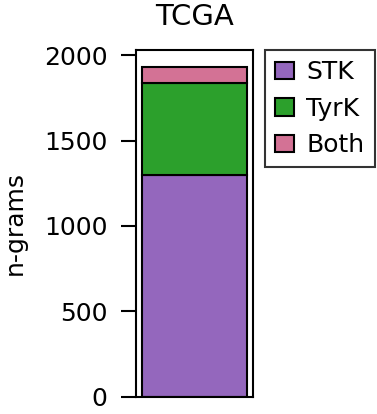

In [25]:
x = pd.Series(ngram_kintype).value_counts()

f, ax = plt.subplots(figsize = (0.5,1.5), dpi = 300)
bottom = 0
for lab,i in x.items():
    ax.bar(0, i,0.5,label=lab, bottom = bottom,
           color = col_map[lab],
           linewidth = 0.5, edgecolor = 'k')
    bottom += i
ax.legend(bbox_to_anchor = [1,1.035],
          fancybox = False,
          edgecolor = 'k',
          handlelength = 0.75, handletextpad = 0.5,
          fontsize=6).get_frame().set_linewidth(0.5)
ax.tick_params(labelbottom = False, bottom=False, labelsize = 6,width = 0.5)

# For the next plot
handles,labels = ax.get_legend_handles_labels()
plt.title('TCGA', fontdict={'fontsize':7})
plt.ylabel('n-grams')
plt.savefig('Figures/Manuscript/Supplemental_Figure_15/S15E_ngram_dist.svg')

Text(0, 0.5, 'Novel n-grams')

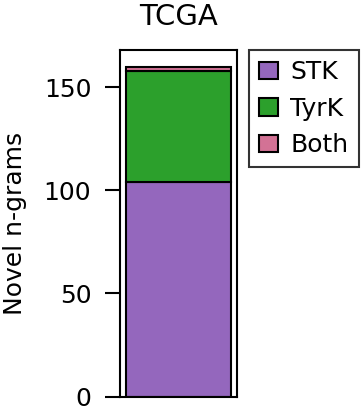

In [26]:
newngram_kintype = {k:v for k,v in ngram_kintype.items() if k in new_ngrams}
x = pd.Series(newngram_kintype).value_counts()
f, ax = plt.subplots(figsize = (0.5,1.5), dpi = 300)
bottom = 0
for lab,i in x.items():
    ax.bar(0, i,0.5,label=lab, bottom = bottom,color = col_map[lab],
           linewidth = 0.5, edgecolor = 'k')
    bottom += i
ax.legend(bbox_to_anchor = [1,1.035],
          fancybox = False,
          edgecolor = 'k',
          handlelength = 0.75, handletextpad = 0.5,
          fontsize=6).get_frame().set_linewidth(0.5)
ax.tick_params(labelbottom = False, bottom=False, labelsize = 6,width = 0.5)

# For the next plot
handles,labels = ax.get_legend_handles_labels()
plt.title('TCGA', fontdict={'fontsize':7})
plt.ylabel('Novel n-grams')
#plt.savefig('Figures/Manuscript/Supplemental_Figure_15/S15E_ngram_dist.svg')

In [27]:
# Now getting the domain n-gram counts for the top 10ish n-grams
ngram_counts = pd.Series(index = [k for k in tcga_ngram_id_dict.keys()], data = [len(v) for v in tcga_ngram_id_dict.values()]).sort_values(ascending=False)


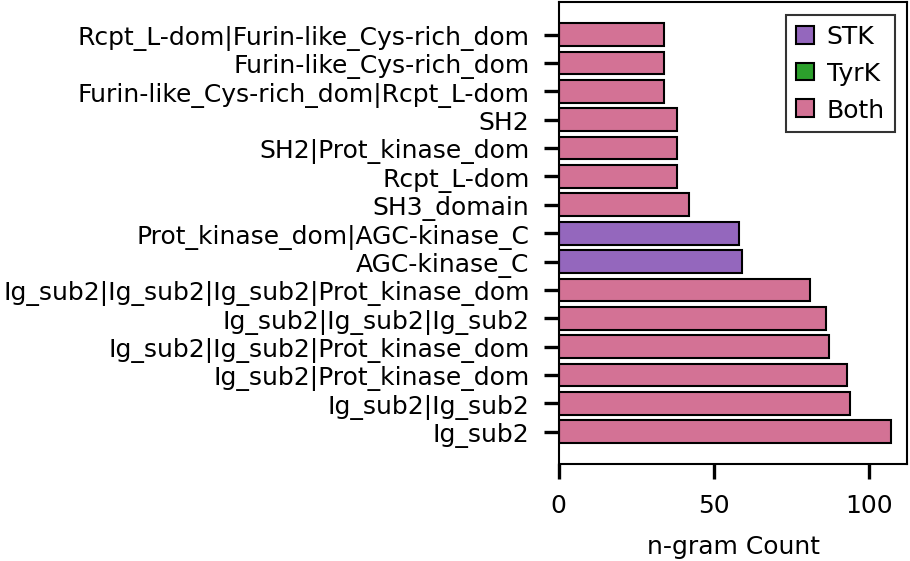

In [28]:
n2show = 15
plt.barh(y = [tcga_prots_net.return_legible_ngram(k) for k in ngram_counts.index[1:n2show+1]], 
        width = ngram_counts[1:n2show+1],
        color = [col_map[ngram_kintype[n]] for n in ngram_counts.index[1:n2show+1]], edgecolor = 'k', linewidth = 0.5)
plt.xlabel('n-gram Count', fontdict={'fontsize':6})
plt.legend(handles, labels,handlelength = 0.75, handletextpad = 0.5,
           fancybox = False, edgecolor = 'k', fontsize = 6).get_frame().set_linewidth(0.5)
plt.gcf().set_dpi(300)
plt.gcf().set_size_inches(1.5,2)
plt.tick_params(labelsize=6)
plt.savefig('Figures/Manuscript/Figure_4/4D_top_ngram_counts.svg')

# Diversity Index calculations
Now let's look at how diverse the kinase domains for both systems are and then relate that to their propensity to make new n-grams in fusions.

In [31]:
# Creating a function to get the diversity index of a specific domain towards either the N-terminal or C-terminal
def get_diversity_index(domain, ngram_list, terminal='N'):
    
    terminal = terminal.lower()
    
    # Now getting the instances
    ngram_counts_OI = Counter(dansy.ngramUtilities.return_ngrams_from_list(ngram_list,2)) #Only extracting 2-grams for these
    if terminal == 'n':
        fin_dom_counts = {k:v for k,v in ngram_counts_OI.items() if (k.split('|')[-1] == domain) and (len(k.split('|')) == 2)} #Just as a safety check
    elif terminal == 'c':
        fin_dom_counts = {k:v for k,v in ngram_counts_OI.items() if (k.split('|')[0] == domain) and (len(k.split('|')) == 2)} #Just as a safety check
    else:
        raise ValueError('An invalid terminal was provided')

    # Creating the dataframe to hold all the information for quick calculations
    fin_diversity_info = pd.DataFrame.from_dict(fin_dom_counts, orient='index', columns = ['n'])
    fin_diversity_info['nn-1'] = fin_diversity_info.n.apply(lambda x: x*(x-1))
    N = fin_diversity_info.n.sum()
    dom_diversity = 1-fin_diversity_info['nn-1'].sum()/(N*(N-1))

    return dom_diversity

def get_domain_ngram_list_with_NC(domain, ref, colname = 'Interpro Domain Architecture IDs'):

    ref_OI = ref[ref[colname].apply(lambda x: domain in x)].copy()
    ngram_list = ref_OI[colname].apply(lambda x: 'N-term|'+x+'|C-term')
    return ngram_list.values

def get_domain_richness(domain, ngram_list, terminal = 'N'):
    
    terminal = terminal.lower()

    ngram_OI = dansy.ngramUtilities.return_ngrams_from_list(ngram_list,2) #Only extracting 2-grams for these
    if terminal == 'n':
        fin_dom_counts = [k for k in ngram_OI if (k.split('|')[-1] == domain) and (len(k.split('|')) == 2)] #Just as a safety check
    elif terminal == 'c':
        fin_dom_counts = [k for k in ngram_OI if (k.split('|')[0] == domain) and (len(k.split('|')) == 2)] #Just as a safety check
    else:
        raise ValueError('An invalid terminal was provided')
    
    return len(fin_dom_counts)

In [32]:
# Get the instance counts for each of the domain n-grams

# First as part of finding the diversity also need to add tokens for the N- and C- terminal ends of the domain architectures
kinase_corpus_list = get_domain_ngram_list_with_NC('IPR000719',kinase_net.ref)
kinase_D_N = get_diversity_index('IPR000719', kinase_corpus_list,'N')
kinase_D_C = get_diversity_index('IPR000719', kinase_corpus_list,'C')
kinase_R_N = get_domain_richness('IPR000719', kinase_corpus_list,'N')
kinase_R_C = get_domain_richness('IPR000719', kinase_corpus_list,'C')
print(f'Diversity index for all STK and TK kinase domains towards the N-terminal: {kinase_D_N} and the C-terminal: {kinase_D_C}')
print(f'Richness for all STK and TK kinase domains towards the N-terminal: {kinase_R_N} and the C-terminal: {kinase_R_C}')

Diversity index for all STK and TK kinase domains towards the N-terminal: 0.6396268405449573 and the C-terminal: 0.548176495224643
Richness for all STK and TK kinase domains towards the N-terminal: 61 and the C-terminal: 49


In [33]:
serthr_kins['Interpro Domain Architecture IDs'].apply(lambda x: x == 'IPR000719').sum()

198

In [34]:
# Now let's repeat that but with only the TKs followed by STKs
kinase_corpus_list = get_domain_ngram_list_with_NC('IPR000719',tyr_kins)
kinase_D_N = get_diversity_index('IPR000719', kinase_corpus_list,'N')
kinase_D_C = get_diversity_index('IPR000719', kinase_corpus_list,'C')
kinase_R_N = get_domain_richness('IPR000719', kinase_corpus_list,'N')
kinase_R_C = get_domain_richness('IPR000719', kinase_corpus_list,'C')
print(f'Diversity index for TK kinase domains towards the N-terminal: {kinase_D_N} and the C-terminal: {kinase_D_C}')
print(f'Richness for TK kinase domains towards the N-terminal: {kinase_R_N} and the C-terminal: {kinase_R_C}')
# Now STKs
kinase_corpus_list = get_domain_ngram_list_with_NC('IPR000719',serthr_kins)
kinase_D_N = get_diversity_index('IPR000719', kinase_corpus_list,'N')
kinase_D_C = get_diversity_index('IPR000719', kinase_corpus_list,'C')
kinase_R_N = get_domain_richness('IPR000719', kinase_corpus_list,'N')
kinase_R_C = get_domain_richness('IPR000719', kinase_corpus_list,'C')
print(f'Diversity index for all STK domains towards the N-terminal: {kinase_D_N} and the C-terminal: {kinase_D_C}')
print(f'Richness for all STK domains towards the N-terminal: {kinase_R_N} and the C-terminal: {kinase_R_C}')

Diversity index for TK kinase domains towards the N-terminal: 0.8498383779018512 and the C-terminal: 0.4401998236849839
Richness for TK kinase domains towards the N-terminal: 19 and the C-terminal: 6
Diversity index for all STK domains towards the N-terminal: 0.4863687614978339 and the C-terminal: 0.5626609696753901
Richness for all STK domains towards the N-terminal: 46 and the C-terminal: 46


Now how diverse are the fusions that retain the kinase domain?

In [35]:
stk_fusions = tcga_kins_only[tcga_kins_only.stk & tcga_kins_only.domain_architecture.apply(lambda x:'IPR000719' in x)].copy()

# Now for the few where there are both an STK and a TK double check where the kinase domain is coming from
stk_fusions['stk_kinase_dom'] = stk_fusions.apply(lambda x: ((x['h_uniprot'] in serthr_kins['UniProt ID'].values) & ('IPR000719' in x['h_contribution'])) | ((x['t_uniprot'] in serthr_kins['UniProt ID'].values) & ('IPR000719' in x['t_contribution'])) , axis = 1)
stk_fusions = stk_fusions[stk_fusions.stk_kinase_dom].filter(['name', 'domain_architecture']).drop_duplicates()
kin_fusion_archs = get_domain_ngram_list_with_NC('IPR000719',stk_fusions, 'domain_architecture')
kinase_D_N = get_diversity_index('IPR000719', kin_fusion_archs,'N')
kinase_D_C = get_diversity_index('IPR000719', kin_fusion_archs,'C')
print(f'Diversity index STK kinase domains towards the N-terminal: {kinase_D_N} and the C-terminal: {kinase_D_C}')

Diversity index STK kinase domains towards the N-terminal: 0.6183388704318937 and the C-terminal: 0.5899888517279821


In [36]:
tk_fusions = tcga_kins_only[tcga_kins_only.tk & tcga_kins_only.domain_architecture.apply(lambda x:'IPR000719' in x)].copy()

# Now for the few where there are both an STK and a TK double check where the kinase domain is coming from
tk_fusions['tk_kinase_dom'] = tk_fusions.apply(lambda x: ((x['h_uniprot'] in tyr_kins['UniProt ID'].values) & ('IPR000719' in x['h_contribution'])) | ((x['t_uniprot'] in tyr_kins['UniProt ID'].values) & ('IPR000719' in x['t_contribution'])) , axis = 1)
tk_fusions = tk_fusions[tk_fusions.tk_kinase_dom].filter(['name', 'domain_architecture']).drop_duplicates()

kin_fusion_archs = get_domain_ngram_list_with_NC('IPR000719',tk_fusions, 'domain_architecture')
kinase_D_N = get_diversity_index('IPR000719', kin_fusion_archs,'N')
kinase_D_C = get_diversity_index('IPR000719', kin_fusion_archs,'C')
print(f'Diversity index TK kinase domains towards the N-terminal: {kinase_D_N} and the C-terminal: {kinase_D_C}')

Diversity index TK kinase domains towards the N-terminal: 0.9128145865434001 and the C-terminal: 0.38636363636363635


# Now let's check overall the Enrichment results and compare to the diversity indices.

In [37]:
full_proteome = dansy.dansy(ref = ref_df, n = 15)

Starting to fetch n-grams.
Finished getting all n-grams
Starting to generate adjacency
Finished building adjacency.


In [38]:
# Importing enrichment results
tcga_dom_enrichment = pd.read_csv('TCGA_Fusion_Domain_Enrichment_Results.csv', index_col = 0)
tcga_dom_enrichment.dropna(subset = 'ngram', inplace=True)
tcga_null_res = pd.read_csv('Null_p_val_dists_15K_tcga.csv',index_col=0)

In [39]:
# Getting only single domains since most of the significantlt enriched n-grams are single domains and not multi-domains
tcga_single_dom = tcga_dom_enrichment[tcga_dom_enrichment['ngram'].apply(lambda x: len(x.split('|')) == 1)].copy()
tcga_single_dom.set_index('ngram',inplace=True)
div_res = []
for ngram in tcga_single_dom.index:
    nlist = get_domain_ngram_list_with_NC(ngram, ref_df)
    if len(nlist) > 1:
        DN = get_diversity_index(ngram, nlist,'N')
        DC = get_diversity_index(ngram, nlist,'C')
    else:
        DN = 0
        DC = 0
    div_res.append((ngram, DN, DC))

In [40]:
# Do a quick FPR check for each domain
fpr_res =[]
for ngram in tcga_single_dom.index:
    if ngram in tcga_null_res.index:
        fpr = tcga_null_res.loc[ngram].le(tcga_single_dom.loc[ngram,'True_q']).sum()/100
    elif tcga_single_dom.loc[ngram,'True_q'] > 0.001:
        fpr = 1
    else:
        fpr = 0
    
    fpr_res.append((ngram,fpr))

In [41]:
div_res_df = pd.DataFrame.from_records(div_res, columns = ['ngram', 'N_term_D', 'C_term_D']).set_index('ngram')
fpr_res_df = pd.DataFrame.from_records(fpr_res, columns = ['ngram','FPR']).set_index('ngram')


In [42]:
dataOI = tcga_single_dom.merge(div_res_df, left_index=True, right_index=True).merge(fpr_res_df, left_index= True, right_index=True)
dataOI['True_q_log'] = dataOI.True_q.apply(lambda x: -1*np.log10(x))
dataOI['fpr_good'] = dataOI.FPR <= 0.05
dataOI['domain_name'] = [full_proteome.return_legible_ngram(i) for i in dataOI.index]

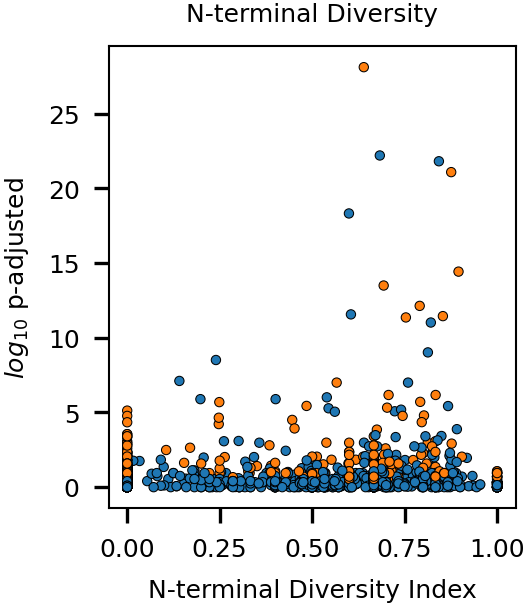

In [43]:
ax = sns.scatterplot(dataOI, x='N_term_D', y = 'True_q_log', 
                     hue = 'fpr_good', s=5, legend = False,
                     linewidth = 0.25, edgecolor = 'k')
plt.xlabel('N-terminal Diversity Index', fontdict={'fontsize':6})
plt.ylabel(r'$log_{10}$ p-adjusted', fontdict={'fontsize':6})
plt.gcf().set_size_inches(1.75,2)
plt.gcf().set_dpi(300)
plt.title('N-terminal Diversity', fontdict={'fontsize':6})
plt.tick_params(labelsize = 6)
plt.savefig('Figures/Manuscript/Figure_4/4Ei_N-terminal_Diversity.svg')

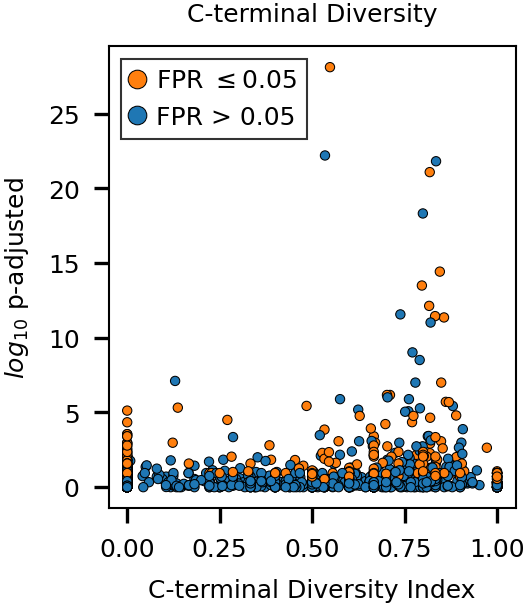

In [44]:
ax = sns.scatterplot(dataOI, x='C_term_D', y = 'True_q_log', hue = 'fpr_good', s = 5,
                     linewidth = 0.25, edgecolor = 'k')
plt.xlabel('C-terminal Diversity Index', fontdict={'fontsize':6})
plt.ylabel(r'$log_{10}$ p-adjusted', fontdict={'fontsize':6})
plt.gcf().set_size_inches(1.75,2)
plt.gcf().set_dpi(300)
plt.title('C-terminal Diversity', fontdict={'fontsize':6})
plt.tick_params(labelsize = 6)
handles,_ = ax.get_legend_handles_labels()
plt.legend(handles = handles[::-1], 
           labels = [r'FPR $\leq$0.05', 'FPR > 0.05'],
           loc = 'upper left', 
           title = None, 
           handletextpad = 0.5,markerscale = 2,handlelength = 0.5,
           fontsize = 6, edgecolor = 'k', fancybox = False).get_frame().set_linewidth(0.5)
plt.savefig('Figures/Manuscript/Figure_4/4Eii_C-terminal_Diversity.svg')